# Mini Lab: Variables X e Y en Matemáticas y Finanzas

Este notebook está diseñado para estudiantes principiantes. Aprenderás, con ejemplos visuales, cómo distinguir **variable independiente (X)** y **variable dependiente (Y)**.

In [ ]:
# Librerías base del lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo simple para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print('Entorno listo. Semilla fija: 42')

: 

## 1) Introducción conceptual

- **Variable independiente (X):** es la referencia o entrada que usamos para explicar o analizar otra variable.
- **Variable dependiente (Y):** es el resultado o respuesta que observamos.
- Muchas veces, X funciona como predictor o input, y Y como respuesta.
- En finanzas, que X esté en el eje horizontal no significa que siempre cause a Y. A veces X se usa solo como referencia para estudiar relaciones.

## 2) Ejemplo físico simple: tiempo y altura

In [2]:
# Datos del ejemplo físico
tiempo = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
altura = [1.7, 1.85, 1.9, 1.85, 1.7, 1.5, 1.15, 0.7]

# Tabla en pandas
df_fisico = pd.DataFrame({
    'tiempo_segundos': tiempo,
    'altura_metros': altura
})

df_fisico

,tiempo_segundos,altura_metros
0,0.0,1.70
1,0.1,1.85
2,0.2,1.90
3,0.3,1.85
4,0.4,1.70
5,0.5,1.50
6,0.6,1.15
7,0.7,0.70


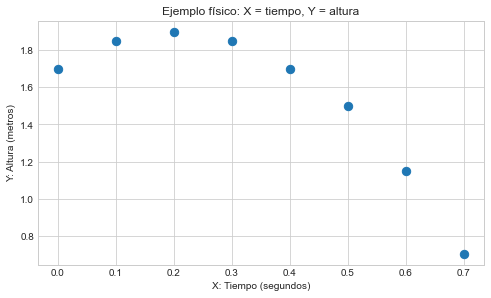

Interpretación breve: el tiempo funciona como referencia (X), y la altura es la respuesta observada (Y).


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(df_fisico['tiempo_segundos'], df_fisico['altura_metros'], color='tab:blue', s=70)

ax.set_title('Ejemplo físico: X = tiempo, Y = altura')
ax.set_xlabel('X: Tiempo (segundos)')
ax.set_ylabel('Y: Altura (metros)')

plt.show()

print('Interpretación breve: el tiempo funciona como referencia (X), y la altura es la respuesta observada (Y).')

## 3) Ejemplo financiero 1: precio en el tiempo

Aquí usamos una acción ficticia durante 30 días. En este caso:
- **X = tiempo (día)**
- **Y = precio**

En finanzas, el tiempo suele ir en X porque ordena y contextualiza la evolución de la serie.

In [4]:
# Serie sintética de precios (30 días) con cambios diarios aleatorios
dias = np.arange(1, 31)
precio_inicial = 100
rend_diario = np.random.normal(loc=0.0008, scale=0.015, size=30)
precios = precio_inicial * np.cumprod(1 + rend_diario)

df_precios = pd.DataFrame({
    'dia': dias,
    'precio': precios
})

df_precios.head()

,dia,precio
0,1,100.825071
1,2,100.696624
2,3,101.755482
3,4,104.161536
4,5,103.879018


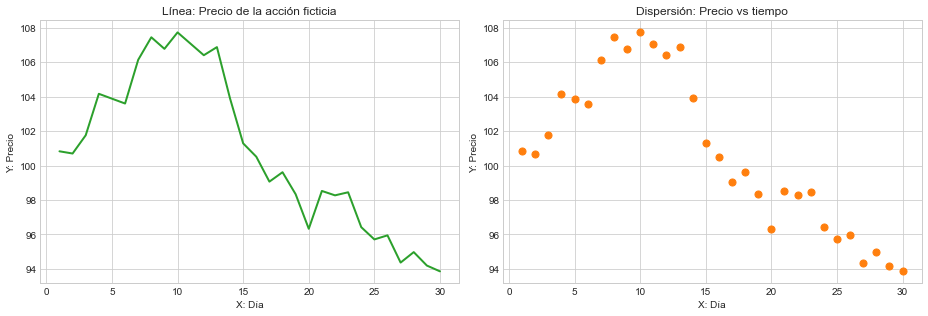

Por qué tiempo en X: porque es la referencia que ordena los datos y permite ver cómo cambia el precio.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico de línea
axes[0].plot(df_precios['dia'], df_precios['precio'], color='tab:green', linewidth=2)
axes[0].set_title('Línea: Precio de la acción ficticia')
axes[0].set_xlabel('X: Día')
axes[0].set_ylabel('Y: Precio')

# Gráfico de dispersión
axes[1].scatter(df_precios['dia'], df_precios['precio'], color='tab:orange', s=50)
axes[1].set_title('Dispersión: Precio vs tiempo')
axes[1].set_xlabel('X: Día')
axes[1].set_ylabel('Y: Precio')

plt.tight_layout()
plt.show()

print('Por qué tiempo en X: porque es la referencia que ordena los datos y permite ver cómo cambia el precio.')

## 4) Ejemplo financiero 2: rendimiento de una acción vs mercado

Ahora comparamos rendimientos:
- **X = rendimiento del mercado**
- **Y = rendimiento de la acción**

Agregamos una línea de tendencia para visualizar sensibilidad (idea intuitiva de beta).

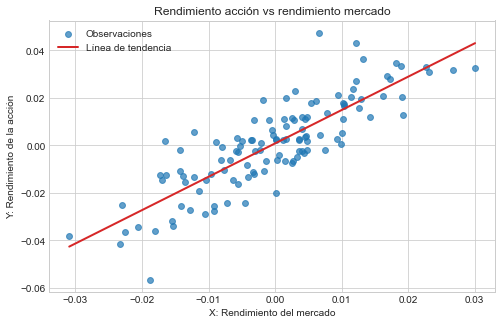

Pendiente estimada (sensibilidad intuitiva tipo beta): 1.40
Lectura simple: si la pendiente es mayor a 1, la acción tiende a moverse más que el mercado.


In [6]:
n = 120
rend_mercado = np.random.normal(loc=0.0005, scale=0.012, size=n)

# Relación lineal simple con ruido: accion = alfa + beta*mercado + ruido
alfa = 0.0002
beta_real = 1.3
ruido = np.random.normal(loc=0, scale=0.01, size=n)
rend_accion = alfa + beta_real * rend_mercado + ruido

df_beta = pd.DataFrame({
    'rend_mercado': rend_mercado,
    'rend_accion': rend_accion
})

# Ajuste lineal para línea de tendencia
coef = np.polyfit(df_beta['rend_mercado'], df_beta['rend_accion'], 1)
pendiente, intercepto = coef
x_linea = np.linspace(df_beta['rend_mercado'].min(), df_beta['rend_mercado'].max(), 100)
y_linea = pendiente * x_linea + intercepto

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_beta['rend_mercado'], df_beta['rend_accion'], alpha=0.7, color='tab:blue', s=35, label='Observaciones')
ax.plot(x_linea, y_linea, color='tab:red', linewidth=2, label='Línea de tendencia')

ax.set_title('Rendimiento acción vs rendimiento mercado')
ax.set_xlabel('X: Rendimiento del mercado')
ax.set_ylabel('Y: Rendimiento de la acción')
ax.legend()

plt.show()

print(f'Pendiente estimada (sensibilidad intuitiva tipo beta): {pendiente:.2f}')
print('Lectura simple: si la pendiente es mayor a 1, la acción tiende a moverse más que el mercado.')

## 5) Ejemplo financiero 3: riesgo vs retorno

Creamos 12 activos ficticios con:
- nombre
- volatilidad (riesgo)
- retorno esperado

Aquí la gráfica se usa para **comparar** activos, no para afirmar causalidad fuerte.

In [7]:
activos = [f'Activo_{i:02d}' for i in range(1, 13)]

# Riesgo entre 8% y 35%
volatilidad = np.round(np.linspace(0.08, 0.35, 12) + np.random.normal(0, 0.01, 12), 3)

# Retorno esperado con patrón creciente + ruido
retorno_esperado = np.round(0.03 + 0.25 * volatilidad + np.random.normal(0, 0.01, 12), 3)

df_activos = pd.DataFrame({
    'activo': activos,
    'volatilidad': volatilidad,
    'retorno_esperado': retorno_esperado
})

df_activos

,activo,volatilidad,retorno_esperado
0,Activo_01,0.094,0.069
1,Activo_02,0.090,0.040
2,Activo_03,0.141,0.087
3,Activo_04,0.154,0.049
4,Activo_05,0.168,0.070
5,Activo_06,0.207,0.088
6,Activo_07,0.229,0.090
7,Activo_08,0.246,0.085
8,Activo_09,0.277,0.097
9,Activo_10,0.297,0.099


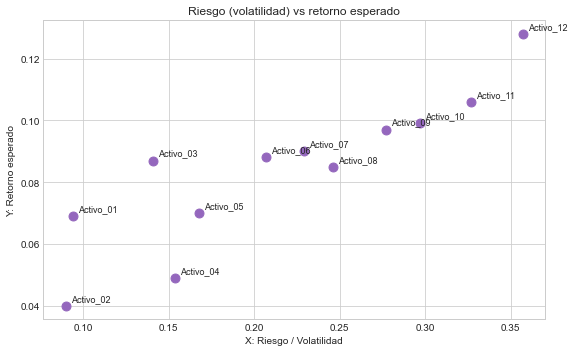

Esta nube de puntos ayuda a comparar activos. No demuestra por sí sola una causalidad fuerte.


In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(df_activos['volatilidad'], df_activos['retorno_esperado'], s=80, color='tab:purple')

# Etiquetas de cada activo
for _, fila in df_activos.iterrows():
    ax.annotate(fila['activo'], (fila['volatilidad'], fila['retorno_esperado']),
                textcoords='offset points', xytext=(5, 5), fontsize=9)

ax.set_title('Riesgo (volatilidad) vs retorno esperado')
ax.set_xlabel('X: Riesgo / Volatilidad')
ax.set_ylabel('Y: Retorno esperado')

plt.show()

print('Esta nube de puntos ayuda a comparar activos. No demuestra por sí sola una causalidad fuerte.')

## 6) Correlación vs causalidad

- **Correlación:** dos variables se mueven juntas en algún patrón.
- **Causalidad:** cambios en una variable producen cambios en la otra.

Una nube de puntos puede mostrar correlación, pero no prueba causalidad.

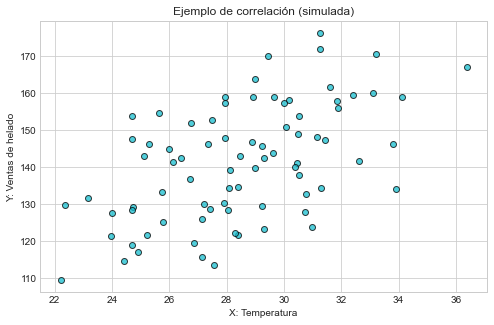

Correlación aproximada: 0.54
Mensaje clave: ver asociación no equivale a probar que X causa Y.


In [9]:
# Ejemplo simulado: temperatura y ventas de helado
# Ambas pueden subir juntas por un tercer factor (estación), sin causalidad directa en todos los contextos.
n = 80
temperatura = np.random.normal(28, 4, n)
ventas_helado = 50 + 3.2 * temperatura + np.random.normal(0, 12, n)

corr = np.corrcoef(temperatura, ventas_helado)[0, 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(temperatura, ventas_helado, color='tab:cyan', edgecolor='black', alpha=0.75)
ax.set_title('Ejemplo de correlación (simulada)')
ax.set_xlabel('X: Temperatura')
ax.set_ylabel('Y: Ventas de helado')
plt.show()

print(f'Correlación aproximada: {corr:.2f}')
print('Mensaje clave: ver asociación no equivale a probar que X causa Y.')

## 7) Mini ejercicios para el estudiante

1. Tienes datos de **horas de estudio** y **nota de examen**. ¿Qué pondrías en X y qué en Y?
2. Si una gráfica muestra X = tasa de interés y Y = precio de bono, ¿cuál variable estás intentando explicar?
3. Observas una nube de puntos ascendente entre rendimiento del mercado y rendimiento de una acción. ¿Eso prueba causalidad? Explica en una frase.
4. En una serie de precio diario, ¿por qué el tiempo suele ir en X aunque no “cause” directamente el precio?
5. Mira una gráfica riesgo-retorno de 12 activos. ¿El objetivo principal es predecir causalidad o comparar alternativas de inversión?

## 8) Resumen final

Reglas prácticas:
- Pon en **X** lo que funciona como referencia, predictor o entrada.
- Pon en **Y** lo que quieres observar, explicar o predecir.
- En finanzas, muchas gráficas muestran relación o asociación, no causalidad.

Usar bien X e Y mejora la interpretación de cualquier análisis.

## Celda opcional: ¿cómo expandir este lab a regresión lineal?

Ideas para seguir:
- Ajustar una regresión lineal simple en el ejemplo de mercado vs acción.
- Comparar una regresión con poco ruido vs mucho ruido.
- Interpretar pendiente e intercepto de forma intuitiva.
- Dividir datos en entrenamiento y prueba para evaluar predicción.